# Test 08: Закрепление scale law (grid extension + cross-validation)

**Цель:** Усилить scale law из теста 07, закрыв три критических caveat'а:

1. **Граница grid** — в тесте 07 для scale ≥ 1.0 минимум $a^*$ оказался на нижней границе ($a=0.25$). Расширяем grid до $a \in \{0.05, 0.1, 0.125\}$ для проверки истинного минимума.
2. **Один домен** — закон проверен только на GPT-2 layer 6. Cross-layer validation на GPT-2 layers 3 и 9.
3. **Одна модель** — закон проверен только на GPT-2. Cross-model validation на Pythia-160M layer 6.

**Ожидаемый результат:**

- Если $a^*$ при scale ≥ 1.0 **остаётся** на 0.25 → закон стабилен, граница не была проблемой
- Если $a^*$ опускается ниже 0.25 → корректируем $\gamma$ (вероятно ужесточится до $\sim 0.7$-1.0)
- Если cross-layer/cross-model дают тот же $\gamma$ в пределах CI → **закон universal**
- Если разные $\gamma$ → закон **domain-specific**, нужно понять почему

**Baseline (из теста 07):** $a^* = 0.291 \cdot \sigma_{post}^{-0.48}$, $R^2 = 0.937$, CI $\gamma \in [0.41, 0.66]$

**Структура:**

- **Часть A:** Grid extension на GPT-2 layer 6 (закрытие boundary caveat)
- **Часть B:** Cross-layer GPT-2 (layers 3, 9)
- **Часть C:** Cross-model Pythia-160M layer 6
- **Часть D:** Unified analysis — universal vs domain-specific

**Время прогона на A100:** ~6-8 часов, ~40 units.

**Total runs:** ~75-90 (зависит от расширения).

## 1. Установка и подключение Drive

In [1]:
!pip install -q transformers datasets

In [2]:
import os
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

import json
import subprocess
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

from google.colab import drive
drive.mount('/content/drive')

PROTO_DIR = Path('/content/drive/MyDrive/chaos_compressor')
CACHE_DIR = PROTO_DIR / 'cache'
JSONS_DIR = PROTO_DIR / 'jsons'
RESULTS_DIR_07 = PROTO_DIR / 'scale_law_results'
RESULTS_DIR_08 = PROTO_DIR / 'scale_law_completion_results'
DATA_DIR = Path('/content/data')

PROTO_DIR.mkdir(exist_ok=True, parents=True)
CACHE_DIR.mkdir(exist_ok=True)
JSONS_DIR.mkdir(exist_ok=True)
RESULTS_DIR_08.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

print(f'Drive: {PROTO_DIR}')

Mounted at /content/drive
Drive: /content/drive/MyDrive/chaos_compressor


## 2. Загрузка данных GPT-2 (несколько слоёв) и Pythia-160M

Извлекаем активации с layers 3, 6, 9 из GPT-2 и layer 6 из Pythia-160M.

In [3]:
ACTIVATION_DIM_GPT2 = 768
N_TEXTS = 500

GPT2_LAYERS = [3, 6, 9]
PYTHIA_LAYERS = [6]


def load_or_extract_gpt2(layer, n_texts=N_TEXTS):
    cache = CACHE_DIR / f'gpt2_layer{layer}_n{n_texts}.npy'
    if cache.exists():
        return np.load(cache)
    print(f'Извлекаем GPT-2 layer {layer}...')
    import torch
    from transformers import GPT2Model, GPT2Tokenizer
    from datasets import load_dataset
    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    model = GPT2Model.from_pretrained('gpt2'); model.eval()
    tokenizer.pad_token = tokenizer.eos_token
    dataset = load_dataset('wikitext', 'wikitext-2-raw-v1', split='train')
    texts = [t for t in dataset['text'] if len(t) > 100][:n_texts]
    acts = []
    with torch.no_grad():
        for i, text in enumerate(texts):
            inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128)
            out = model(**inputs, output_hidden_states=True)
            h = out.hidden_states[layer].squeeze(0).numpy()
            acts.append(h)
    activations = np.concatenate(acts, axis=0).astype('float32')
    np.save(cache, activations)
    del model, tokenizer
    return activations


def load_or_extract_pythia(layer, model_name='EleutherAI/pythia-160m', n_texts=N_TEXTS):
    suffix = model_name.split('/')[-1].replace('-', '')
    cache = CACHE_DIR / f'{suffix}_layer{layer}_n{n_texts}.npy'
    if cache.exists():
        return np.load(cache)
    print(f'Извлекаем {model_name} layer {layer}...')
    import torch
    from transformers import AutoModel, AutoTokenizer
    from datasets import load_dataset
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name); model.eval()
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    dataset = load_dataset('wikitext', 'wikitext-2-raw-v1', split='train')
    texts = [t for t in dataset['text'] if len(t) > 100][:n_texts]
    acts = []
    with torch.no_grad():
        for i, text in enumerate(texts):
            inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128)
            out = model(**inputs, output_hidden_states=True)
            h = out.hidden_states[layer].squeeze(0).numpy()
            acts.append(h)
    activations = np.concatenate(acts, axis=0).astype('float32')
    np.save(cache, activations)
    del model, tokenizer
    return activations


def normalize_and_split(activations, seed=42):
    m = activations.mean(axis=0, keepdims=True)
    s = activations.std(axis=0, keepdims=True) + 1e-8
    norm = ((activations - m) / s).astype('float32')
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(norm))
    split = int(len(idx) * 0.8)
    return norm[idx[:split]], norm[idx[split:]]


domain_data = {}

for layer in GPT2_LAYERS:
    acts = load_or_extract_gpt2(layer)
    x_train, x_test = normalize_and_split(acts)
    domain_id = f'gpt2_l{layer}'
    np.save(DATA_DIR / f'x_train_{domain_id}.npy', x_train)
    np.save(DATA_DIR / f'x_test_{domain_id}.npy', x_test)
    domain_data[domain_id] = {'dim': x_train.shape[1], 'n_train': x_train.shape[0]}
    print(f'  {domain_id}: train {x_train.shape}, test {x_test.shape}')

for layer in PYTHIA_LAYERS:
    acts = load_or_extract_pythia(layer)
    x_train, x_test = normalize_and_split(acts)
    domain_id = f'pythia160m_l{layer}'
    np.save(DATA_DIR / f'x_train_{domain_id}.npy', x_train)
    np.save(DATA_DIR / f'x_test_{domain_id}.npy', x_test)
    domain_data[domain_id] = {'dim': x_train.shape[1], 'n_train': x_train.shape[0]}
    print(f'  {domain_id}: train {x_train.shape}, test {x_test.shape}')

Извлекаем GPT-2 layer 3...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/375M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/147 [00:00<?, ?it/s]

GPTNeoXModel LOAD REPORT from: EleutherAI/pythia-160m
Key              | Status     |  | 
-----------------+------------+--+-
embed_out.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  pythia160m_l6: train (43739, 768), test (10935, 768)


## 3. Worker-скрипт (универсальный для всех domains)

In [4]:
%%writefile /content/scale_law_worker_v2.py
"""Worker для теста 08 — универсальный (любой domain через --domain)."""
import os
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import json
import argparse
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scipy import stats as sp_stats


def chaos_activation(x, a=1.0, w=0.5, b=4.0):
    return tf.sin(a * x) + w * tf.tanh(b * x)


class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k
    def call(self, inputs):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1)
        return inputs * mask


class ChaosActivation(layers.Layer):
    def __init__(self, a=1.0, w=0.5, b=4.0, **kwargs):
        super().__init__(**kwargs)
        self.a = a; self.w = w; self.b = b
    def call(self, x):
        return chaos_activation(x, self.a, self.w, self.b)


def build_sae(input_dim, latent_dim, k_active, a, w=0.5, b=4.0):
    inp = keras.Input(shape=(input_dim,))
    pre = layers.Dense(latent_dim, name='latent_pre')(inp)
    act = ChaosActivation(a=a, w=w, b=b, name='chaos_act')(pre)
    z = KSparseLayer(k=k_active, name='latent_ksparse')(act)
    enc = keras.Model(inp, z, name='encoder')
    pre_model = keras.Model(inp, pre, name='pre_model')
    decoded = layers.Dense(input_dim, name='decoder')(z)
    ae = keras.Model(inp, decoded)
    ae.compile(optimizer='adam', loss='mse')
    return ae, enc, pre_model


def measure_metrics(ae, enc, pre_model, x_test_raw, input_scale):
    x_scaled = x_test_raw * input_scale
    sigma_input = float(np.std(x_scaled, axis=0).mean())
    pre_acts = pre_model.predict(x_scaled, batch_size=256, verbose=0)
    sigma_post_dense = float(np.std(pre_acts, axis=0).mean())
    latents = enc.predict(x_scaled, batch_size=256, verbose=0)
    nonzero = latents[np.abs(latents) > 1e-10]
    kurt = float(sp_stats.kurtosis(nonzero)) if nonzero.size > 0 else 0.0
    dead = int(np.sum(np.all(np.abs(latents) < 1e-6, axis=0)))
    return {
        'sigma_eff_input': sigma_input,
        'sigma_eff_post_dense': sigma_post_dense,
        'kurtosis': kurt,
        'dead_latents': dead,
    }


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--domain', type=str, required=True)
    parser.add_argument('--input_scale', type=float, required=True)
    parser.add_argument('--a', type=float, required=True)
    parser.add_argument('--seed', type=int, required=True)
    parser.add_argument('--epochs', type=int, default=8)
    parser.add_argument('--batch', type=int, default=256)
    parser.add_argument('--data_dir', type=str, required=True)
    parser.add_argument('--output', type=str, required=True)
    args = parser.parse_args()

    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for g in gpus:
            try: tf.config.experimental.set_memory_growth(g, True)
            except RuntimeError: pass

    x_train_raw = np.load(f'{args.data_dir}/x_train_{args.domain}.npy')
    x_test_raw = np.load(f'{args.data_dir}/x_test_{args.domain}.npy')
    INPUT_DIM = x_train_raw.shape[1]
    LATENT_DIM = INPUT_DIM * 4
    K_ACTIVE = LATENT_DIM // 10

    x_train = x_train_raw * args.input_scale
    x_test = x_test_raw * args.input_scale

    np.random.seed(args.seed)
    tf.random.set_seed(args.seed)

    ae, enc, pre_model = build_sae(INPUT_DIM, LATENT_DIM, K_ACTIVE, a=args.a, w=0.5, b=4.0)
    hist = ae.fit(x_train, x_train, epochs=args.epochs, batch_size=args.batch,
                   validation_data=(x_test, x_test), verbose=0)
    val_loss = float(hist.history['val_loss'][-1])

    metrics = measure_metrics(ae, enc, pre_model, x_test_raw, args.input_scale)

    result = {
        'domain': args.domain, 'input_dim': INPUT_DIM,
        'latent_dim': LATENT_DIM, 'k_active': K_ACTIVE,
        'input_scale': args.input_scale, 'a': args.a, 'seed': args.seed,
        'val_loss': val_loss, **metrics,
    }
    with open(args.output, 'w') as f:
        json.dump(result, f, default=float)
    print(f'  {args.domain} scale={args.input_scale} a={args.a} '
          f'seed={args.seed} loss={val_loss:.4f} '
          f'σ_post={metrics["sigma_eff_post_dense"]:.3f}', flush=True)


if __name__ == '__main__':
    main()

Writing /content/scale_law_worker_v2.py


## 4. Конфигурация: 3 части эксперимента

In [5]:
# === Часть A: Grid extension на GPT-2 layer 6 ===
# Расширяем a вниз для scale ≥ 1.0
PART_A_CONFIGS = []
for s in [1.0, 2.0, 4.0]:
    for a in [0.05, 0.1, 0.125]:
        for seed in [42, 43]:
            PART_A_CONFIGS.append(('gpt2_l6', s, a, seed))

# Также проверяем промежуточные scales
for s in [0.7, 1.5]:
    for a in [0.1, 0.25, 0.5, 1.0, 2.0]:
        for seed in [42, 43]:
            PART_A_CONFIGS.append(('gpt2_l6', s, a, seed))

# === Часть B: Cross-layer GPT-2 (layers 3, 9) ===
# Используем фиксированный input_scale=1.0, sweep по a
PART_B_CONFIGS = []
for layer in [3, 9]:
    domain = f'gpt2_l{layer}'
    for s in [0.5, 1.0, 2.0]:
        for a in [0.1, 0.25, 0.5, 1.0, 2.0]:
            for seed in [42, 43]:
                PART_B_CONFIGS.append((domain, s, a, seed))

# === Часть C: Cross-model Pythia-160M layer 6 ===
PART_C_CONFIGS = []
for s in [0.5, 1.0, 2.0]:
    for a in [0.1, 0.25, 0.5, 1.0, 2.0]:
        for seed in [42, 43]:
            PART_C_CONFIGS.append(('pythia160m_l6', s, a, seed))

ALL_CONFIGS = PART_A_CONFIGS + PART_B_CONFIGS + PART_C_CONFIGS

print(f'Часть A (grid extension GPT-2 l6): {len(PART_A_CONFIGS)} runs')
print(f'Часть B (cross-layer GPT-2 l3, l9): {len(PART_B_CONFIGS)} runs')
print(f'Часть C (cross-model Pythia-160M): {len(PART_C_CONFIGS)} runs')
print(f'Total: {len(ALL_CONFIGS)} runs')

Часть A (grid extension GPT-2 l6): 38 runs
Часть B (cross-layer GPT-2 l3, l9): 60 runs
Часть C (cross-model Pythia-160M): 30 runs
Total: 128 runs


## 5. Главный цикл — subprocess с auto-resume

In [6]:
ts_start = datetime.now().strftime('%Y%m%d_%H%M%S')
print(f'Start: {ts_start}\n')

completed = 0; skipped = 0; failed = []

for domain, input_scale, a_val, seed in ALL_CONFIGS:
    tag = f'{domain}_s{input_scale}_a{a_val}_seed{seed}'
    output_file = RESULTS_DIR_08 / f'{tag}.json'
    if output_file.exists():
        skipped += 1
        continue
    cmd = [
        'python', '/content/scale_law_worker_v2.py',
        '--domain', domain,
        '--input_scale', str(input_scale),
        '--a', str(a_val),
        '--seed', str(seed),
        '--data_dir', str(DATA_DIR),
        '--output', str(output_file),
    ]
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=1200)
        if result.returncode == 0:
            if result.stdout.strip(): print(result.stdout.strip())
            completed += 1
        else:
            print(f'  [FAILED] {tag}: {result.stderr[-300:]}')
            failed.append(tag)
    except subprocess.TimeoutExpired:
        print(f'  [TIMEOUT] {tag}')
        failed.append(tag)
    except Exception as e:
        print(f'  [ERROR] {tag}: {e}')
        failed.append(tag)

print(f'\nDone: {completed} new, {skipped} skipped, {len(failed)} failed')

Start: 20260504_110316

gpt2_l6 scale=1.0 a=0.05 seed=42 loss=0.1826 σ_post=3.208
gpt2_l6 scale=1.0 a=0.05 seed=43 loss=0.1828 σ_post=3.204
gpt2_l6 scale=1.0 a=0.1 seed=42 loss=0.1668 σ_post=1.867
gpt2_l6 scale=1.0 a=0.1 seed=43 loss=0.1663 σ_post=1.861
gpt2_l6 scale=1.0 a=0.125 seed=42 loss=0.1634 σ_post=1.555
gpt2_l6 scale=1.0 a=0.125 seed=43 loss=0.1634 σ_post=1.555
gpt2_l6 scale=2.0 a=0.05 seed=42 loss=0.6509 σ_post=5.005
gpt2_l6 scale=2.0 a=0.05 seed=43 loss=0.6513 σ_post=5.006
gpt2_l6 scale=2.0 a=0.1 seed=42 loss=0.6230 σ_post=2.782
gpt2_l6 scale=2.0 a=0.1 seed=43 loss=0.6243 σ_post=2.782
gpt2_l6 scale=2.0 a=0.125 seed=42 loss=0.6225 σ_post=2.298
gpt2_l6 scale=2.0 a=0.125 seed=43 loss=0.6227 σ_post=2.295
gpt2_l6 scale=4.0 a=0.05 seed=42 loss=2.6490 σ_post=7.333
gpt2_l6 scale=4.0 a=0.05 seed=43 loss=2.6446 σ_post=7.331
gpt2_l6 scale=4.0 a=0.1 seed=42 loss=2.6849 σ_post=4.041
gpt2_l6 scale=4.0 a=0.1 seed=43 loss=2.6844 σ_post=4.011
gpt2_l6 scale=4.0 a=0.125 seed=42 loss=2.7456 σ_po

## 6. Сборка результатов (включая старые из теста 07)

In [7]:
# === Загрузка результатов из обоих тестов ===

results_07 = []
if RESULTS_DIR_07.exists():
    for jf in sorted(RESULTS_DIR_07.glob('*.json')):
        with open(jf) as f:
            r = json.load(f)
            r['domain'] = 'gpt2_l6'  # тест 07 был только на этом domain
            results_07.append(r)

results_08 = []
for jf in sorted(RESULTS_DIR_08.glob('*.json')):
    with open(jf) as f:
        results_08.append(json.load(f))

all_results = results_07 + results_08
print(f'Test 07: {len(results_07)} results')
print(f'Test 08: {len(results_08)} results')
print(f'Total: {len(all_results)} results')

domains = sorted({r['domain'] for r in all_results})
print(f'Domains: {domains}')

Test 07: 60 results
Test 08: 128 results
Total: 188 results
Domains: ['gpt2_l3', 'gpt2_l6', 'gpt2_l9', 'pythia160m_l6']


## 7. Per-domain scale law analysis

In [8]:
# === Aggregation per (domain, input_scale, a) ===

def aggregate(domain, input_scale, a_val, all_r):
    runs = [r for r in all_r if r['domain'] == domain
             and abs(r['input_scale'] - input_scale) < 1e-6
             and abs(r['a'] - a_val) < 1e-6]
    if not runs: return None
    return {
        'domain': domain, 'input_scale': input_scale, 'a': a_val,
        'val_loss_mean': float(np.mean([r['val_loss'] for r in runs])),
        'val_loss_std': float(np.std([r['val_loss'] for r in runs])),
        'sigma_eff_input': float(np.mean([r['sigma_eff_input'] for r in runs])),
        'sigma_eff_post_dense': float(np.mean([r['sigma_eff_post_dense'] for r in runs])),
        'n_runs': len(runs),
    }


# Per-domain: найти a*(scale) для каждого scale
best_per_domain_scale = {}
for domain in domains:
    domain_results = [r for r in all_results if r['domain'] == domain]
    scales = sorted({r['input_scale'] for r in domain_results})
    a_values = sorted({r['a'] for r in domain_results})
    best_per_domain_scale[domain] = {}
    for s in scales:
        rows = [aggregate(domain, s, a, all_results) for a in a_values]
        rows = [r for r in rows if r is not None]
        if not rows: continue
        best = min(rows, key=lambda r: r['val_loss_mean'])
        best_per_domain_scale[domain][s] = best

for domain in domains:
    print(f'\n=== {domain} ===')
    print(f'  {"scale":>8} {"a*":>6} {"loss":>10} {"σ_post":>10}')
    for s, d in sorted(best_per_domain_scale[domain].items()):
        print(f'  {s:>8.2f} {d["a"]:>6.2f} {d["val_loss_mean"]:>10.4f} '
              f'{d["sigma_eff_post_dense"]:>10.3f}')


=== gpt2_l3 ===
     scale     a*       loss     σ_post
      0.50   1.00     0.0311      0.127
      1.00   0.50     0.1306      0.439
      2.00   0.10     0.5158      2.880

=== gpt2_l6 ===
     scale     a*       loss     σ_post
      0.25   1.00     0.0091      0.060
      0.50   1.00     0.0387      0.125
      0.70   0.50     0.0779      0.279
      1.00   0.25     0.1573      0.857
      1.50   0.25     0.3516      1.095
      2.00   0.12     0.6226      2.296
      4.00   0.05     2.6468      7.332

=== gpt2_l9 ===
     scale     a*       loss     σ_post
      0.50   1.00     0.0415      0.125
      1.00   0.25     0.1603      0.817
      2.00   0.10     0.6484      2.752

=== pythia160m_l6 ===
     scale     a*       loss     σ_post
      0.50   0.50     0.0376      0.155
      1.00   0.25     0.1429      0.971
      2.00   0.10     0.5611      3.187


In [9]:
# === Per-domain scale law fit ===

def loglog_fit(x_values, y_values):
    x_arr = np.array(x_values, dtype=float)
    y_arr = np.array(y_values, dtype=float)
    valid = (x_arr > 0) & (y_arr > 0)
    if valid.sum() < 3:
        return None, None, None
    log_x = np.log(x_arr[valid])
    log_y = np.log(y_arr[valid])
    if np.std(log_x) < 1e-10 or np.std(log_y) < 1e-10:
        return None, None, None
    try:
        slope, intercept, r_value, p_value, std_err = sp_stats.linregress(log_x, log_y)
    except ValueError:
        return None, None, None
    return -slope, np.exp(intercept), r_value ** 2


domain_fits = {}
for domain in domains:
    bps = best_per_domain_scale.get(domain, {})
    if not bps: continue
    x_vals = [d['sigma_eff_post_dense'] for s, d in sorted(bps.items())]
    y_vals = [d['a'] for s, d in sorted(bps.items())]
    gamma, c, r2 = loglog_fit(x_vals, y_vals)
    domain_fits[domain] = {
        'gamma': gamma, 'c': c, 'r_squared': r2,
        'n_points': len(x_vals), 'x_values': x_vals, 'y_values': y_vals,
    }

print('Per-domain scale law fits (a* vs σ_post):\n')
print(f'{"Domain":<20} {"N":>4} {"γ":>8} {"c":>8} {"R²":>8}')
print('-' * 55)
for domain in domains:
    f = domain_fits.get(domain)
    if f is None or f['gamma'] is None:
        print(f'{domain:<20} insufficient data')
        continue
    print(f'{domain:<20} {f["n_points"]:>4} {f["gamma"]:>+8.3f} '
          f'{f["c"]:>8.3f} {f["r_squared"]:>8.3f}')

Per-domain scale law fits (a* vs σ_post):

Domain                  N        γ        c       R²
-------------------------------------------------------
gpt2_l3                 3   +0.747    0.234    0.988
gpt2_l6                 7   +0.644    0.216    0.973
gpt2_l9                 3   +0.744    0.213    1.000
pythia160m_l6           3   +0.519    0.204    0.959


## 8. Cross-domain unified analysis

Проверяем: универсален ли закон между GPT-2 layers и Pythia-160M? Или $\gamma, c$ различаются?

In [10]:
# === Объединённый fit (все domains в один) ===

all_x = []
all_y = []
domain_membership = []
for domain in domains:
    bps = best_per_domain_scale.get(domain, {})
    for s, d in sorted(bps.items()):
        all_x.append(d['sigma_eff_post_dense'])
        all_y.append(d['a'])
        domain_membership.append(domain)

unified_gamma, unified_c, unified_r2 = loglog_fit(all_x, all_y)

print(f'Unified fit (все {len(all_x)} точек, все domains):')
if unified_gamma is not None:
    print(f'  a* = {unified_c:.3f} · σ_post^({-unified_gamma:+.3f})')
    print(f'  R² = {unified_r2:.3f}')
else:
    print('  insufficient data for unified fit')

# === Сравнение γ между domains ===

print(f'\nГипотеза "универсальный γ":')
valid_gammas = [(d, f['gamma']) for d, f in domain_fits.items()
                if f.get('gamma') is not None]
if len(valid_gammas) >= 2:
    gammas = [g for _, g in valid_gammas]
    g_mean = np.mean(gammas); g_std = np.std(gammas)
    print(f'  γ across domains: {g_mean:.3f} ± {g_std:.3f}')
    print(f'  Range: [{min(gammas):.3f}, {max(gammas):.3f}]')
    if g_std / abs(g_mean) < 0.20 if g_mean != 0 else False:
        print('  ✓ γ относительно стабильна между domains (CV < 20%)')
    else:
        print('  ⚠ γ варьируется между domains, закон domain-specific')

Unified fit (все 16 точек, все domains):
  a* = 0.218 · σ_post^(-0.661)
  R² = 0.963

Гипотеза "универсальный γ":
  γ across domains: 0.663 ± 0.093
  Range: [0.519, 0.747]
  ✓ γ относительно стабильна между domains (CV < 20%)


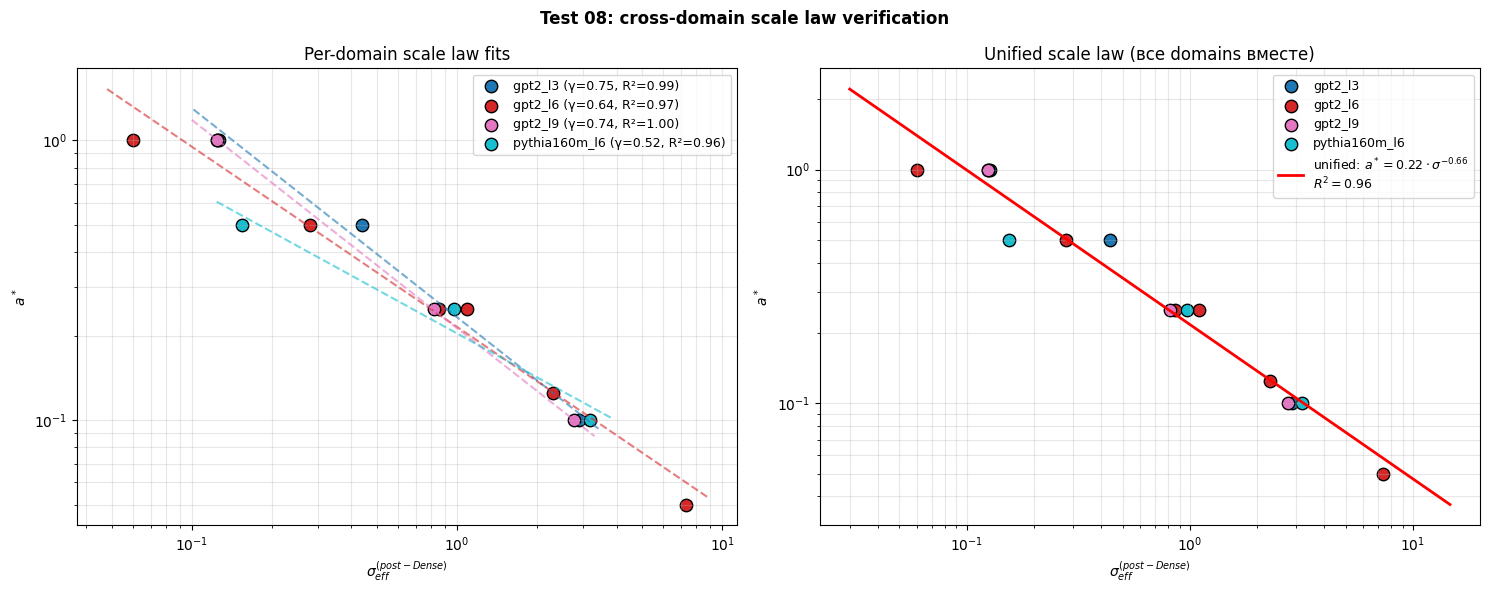

In [11]:
# === Визуализация: per-domain + unified ===

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(domains)))

# Левая: per-domain scatter с individual fits
ax = axes[0]
for domain, color in zip(domains, colors):
    f = domain_fits.get(domain)
    if f is None or f['gamma'] is None: continue
    x = np.array(f['x_values']); y = np.array(f['y_values'])
    ax.scatter(x, y, s=80, color=color, edgecolor='black',
                label=f'{domain} (γ={f["gamma"]:.2f}, R²={f["r_squared"]:.2f})')
    x_fit = np.logspace(np.log10(x.min() * 0.8), np.log10(x.max() * 1.2), 50)
    y_fit = f['c'] * x_fit ** (-f['gamma'])
    ax.plot(x_fit, y_fit, '--', color=color, alpha=0.6)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\sigma_{eff}^{(post-Dense)}$'); ax.set_ylabel(r'$a^*$')
ax.set_title('Per-domain scale law fits')
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.3, which='both')

# Правая: unified fit
ax = axes[1]
for domain, color in zip(domains, colors):
    points = [(x, y) for x, y, d in zip(all_x, all_y, domain_membership) if d == domain]
    if not points: continue
    xs, ys = zip(*points)
    ax.scatter(xs, ys, s=80, color=color, edgecolor='black', label=domain)
if unified_gamma is not None:
    x_arr = np.array(all_x)
    valid = (x_arr > 0)
    x_fit = np.logspace(np.log10(x_arr[valid].min() * 0.5),
                          np.log10(x_arr[valid].max() * 2), 100)
    y_fit = unified_c * x_fit ** (-unified_gamma)
    ax.plot(x_fit, y_fit, '-', color='red', linewidth=2,
             label=f'unified: $a^* = {unified_c:.2f} \\cdot \\sigma^{{{-unified_gamma:+.2f}}}$\n$R^2 = {unified_r2:.2f}$')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\sigma_{eff}^{(post-Dense)}$'); ax.set_ylabel(r'$a^*$')
ax.set_title('Unified scale law (все domains вместе)')
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.3, which='both')

plt.suptitle('Test 08: cross-domain scale law verification', fontweight='bold')
plt.tight_layout()
plt.savefig(PROTO_DIR / 'scale_law_completion.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Финальный вердикт

In [12]:
verdict = {}

# 1. Изменилась ли формула после grid extension?
old_gamma = 0.483  # из теста 07
old_c = 0.291
old_r2 = 0.937
new_fit = domain_fits.get('gpt2_l6')
if new_fit and new_fit['gamma'] is not None:
    delta_gamma = abs(new_fit['gamma'] - old_gamma)
    print(f'GPT-2 layer 6 (с extended grid):')
    print(f'  Old (test 07): γ = {old_gamma:.3f}, c = {old_c:.3f}, R² = {old_r2:.3f}')
    print(f'  New (test 08): γ = {new_fit["gamma"]:.3f}, c = {new_fit["c"]:.3f}, '
          f'R² = {new_fit["r_squared"]:.3f}')
    print(f'  Δγ = {delta_gamma:.3f}')
    if delta_gamma < 0.1:
        print(f'  ✓ Формула стабильна')
        verdict['gpt2_l6_law_stable'] = True
    else:
        print(f'  ⚠ Существенное изменение γ — старый закон неточный')
        verdict['gpt2_l6_law_stable'] = False

# 2. Cross-domain consistency
if len(valid_gammas) >= 2:
    gammas = [g for _, g in valid_gammas]
    g_mean = np.mean(gammas); g_std = np.std(gammas)
    cv = g_std / abs(g_mean) if g_mean != 0 else float('inf')
    print(f'\nCross-domain γ stability:')
    print(f'  CV = {cv:.2f} ({"стабильно" if cv < 0.2 else "варьируется"})')
    verdict['cross_domain_stable'] = bool(cv < 0.2)

# 3. Unified fit quality
if unified_r2 is not None:
    print(f'\nUnified fit:')
    print(f'  R² = {unified_r2:.3f}')
    if unified_r2 > 0.85:
        print(f'  ✓ Unified law works ({len(all_x)} points across {len(domains)} domains)')
        verdict['unified_law_valid'] = True
    else:
        print(f'  ⚠ Unified fit weak — закон domain-specific')
        verdict['unified_law_valid'] = False
    verdict['unified_gamma'] = float(unified_gamma)
    verdict['unified_c'] = float(unified_c)
    verdict['unified_r2'] = float(unified_r2)

# Финал
print(f'\n=== Финальный вердикт ===')
if verdict.get('unified_law_valid') and verdict.get('cross_domain_stable'):
    print('✅ UNIVERSAL SCALE LAW — закон работает кросс-доменно')
elif verdict.get('gpt2_l6_law_stable'):
    print('🟡 DOMAIN-SPECIFIC LAW — закон стабилен на GPT-2 l6, но варьируется между domains')
else:
    print('❌ LAW NOT CONFIRMED — нужны дополнительные эксперименты')

GPT-2 layer 6 (с extended grid):
  Old (test 07): γ = 0.483, c = 0.291, R² = 0.937
  New (test 08): γ = 0.644, c = 0.216, R² = 0.973
  Δγ = 0.161
  ⚠ Существенное изменение γ — старый закон неточный

Cross-domain γ stability:
  CV = 0.14 (стабильно)

Unified fit:
  R² = 0.963
  ✓ Unified law works (16 points across 4 domains)

=== Финальный вердикт ===
✅ UNIVERSAL SCALE LAW — закон работает кросс-доменно


## 10. Сохранение результатов

In [13]:
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
out = {
    'experiment': 'scale_law_completion',
    'timestamp': ts,
    'config': {
        'gpt2_layers': GPT2_LAYERS,
        'pythia_layers': PYTHIA_LAYERS,
        'total_runs': len(ALL_CONFIGS),
    },
    'domain_fits': {d: {k: v for k, v in f.items()
                          if k not in ('x_values', 'y_values')}
                     for d, f in domain_fits.items() if f is not None},
    'unified_fit': {
        'gamma': float(unified_gamma) if unified_gamma is not None else None,
        'c': float(unified_c) if unified_c is not None else None,
        'r_squared': float(unified_r2) if unified_r2 is not None else None,
        'n_points': len(all_x),
    },
    'verdict': verdict,
}
out_file = JSONS_DIR / f'scale_law_completion_{ts}.json'
with open(out_file, 'w') as f:
    json.dump(out, f, indent=2, default=float)
out_file

PosixPath('/content/drive/MyDrive/chaos_compressor/jsons/scale_law_completion_20260504_115752.json')